# Livrable 1 Recherche opérationnelle
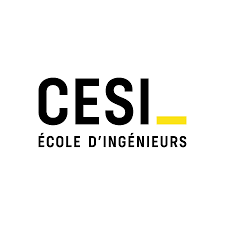
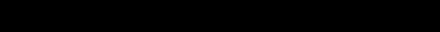

## Rappel des différents problèmes :

## Groupe projet  :
##### Fayçal AÏT TAHT
##### Baptiste NOISETTE
##### Ambroise FAVRY
##### Quentin DUBOIS
##### Lukas PRÊTRE




# Sommaire :
### -  1. Recontextualisation
##### &nbsp;&nbsp;&nbsp;&nbsp; •	1. Introduction et Contexte
##### &nbsp;&nbsp;&nbsp;&nbsp; •	2. Le cas d'usage : CesiCDP, acteur de la Mobilité Multimodale Intelligente
##### &nbsp;&nbsp;&nbsp;&nbsp; •	3. Objectifs métiers : Ce que nous cherchons à accomplir
##### &nbsp;&nbsp;&nbsp;&nbsp; •	4. Justification des contraintes : Rapprocher le modèle de la réalité du terrain
### - 2. État de l'art
##### &nbsp;&nbsp;&nbsp;&nbsp; • 1. Le Problème du Voyageur de Commerce (TSP) et ses variantes
##### &nbsp;&nbsp;&nbsp;&nbsp; • 2. Méthodes exactes
##### &nbsp;&nbsp;&nbsp;&nbsp; • 3. Heuristiques et Méta-heuristiques
### -  3. Analyse de la Complexité Théorique du Problème
##### &nbsp;&nbsp;&nbsp;&nbsp; 1. Pourquoi évaluer la difficulté de notre problème ?
##### &nbsp;&nbsp;&nbsp;&nbsp; 2. Énoncé du Théorème
##### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; A. Le Problème de Décision
##### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; B. L'Algorithme de Vérification
##### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; C. Preuve de NP-Complétude du Problème du Voyageur de Commerce (TSP)
### -  4.Modélisation formelle du Problème de Tournée (TSPTW)
##### &nbsp;&nbsp;&nbsp;&nbsp; •	1. Contexte et enjeux (ADEME)
##### &nbsp;&nbsp;&nbsp;&nbsp; •	2. Définition du Graphe, des Paramètres et des Variables
##### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; A. Le Graphe et les Ensembles
##### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; B. Les Paramètres (Données d'entrée)
##### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; C. Les Variables de Décision (Ce que l'algorithme doit trouver)
##### &nbsp;&nbsp;&nbsp;&nbsp; •	3. Modélisation Mathématique
##### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; A. La Fonction Objectif
##### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; B. Contraintes de Parcours
##### &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; C. Contraintes de Fenêtres Temporelles et Sous-tournées
### -  5. Choix des méthodes de résolution
##### &nbsp;&nbsp;&nbsp;&nbsp; •	1. La méthode exacte : Programmation Linéaire (PL) avec solveur
##### &nbsp;&nbsp;&nbsp;&nbsp; •	2. L'algorithme heuristique
##### &nbsp;&nbsp;&nbsp;&nbsp; •	3. L'algorithme méta-heuristique

### -  6. Conclusion
### -  7. Ressources


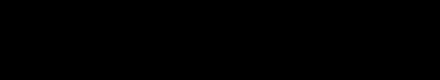

# Section 1 : Recontextualisation
### 1 : Introduction et Contexte
#### Contexte global : L'urgence d'une transition écologique des territoires

Face à l'urgence climatique mondiale, la réduction des émissions de gaz à effet de serre (GES) est devenue une priorité absolue.
C'est dans cette dynamique vitale que s'inscrit l'Appel à Manifestation d'Intérêt (AMI) lancé par l'ADEME (Agence de l'Environnement et de la Maîtrise de l'Énergie). L'objectif de cet AMI est clair : déployer de nouvelles solutions de mobilité pour les personnes et les marchandises, capables de s'adapter aux réalités de chaque territoire tout en limitant leur impact environnemental.



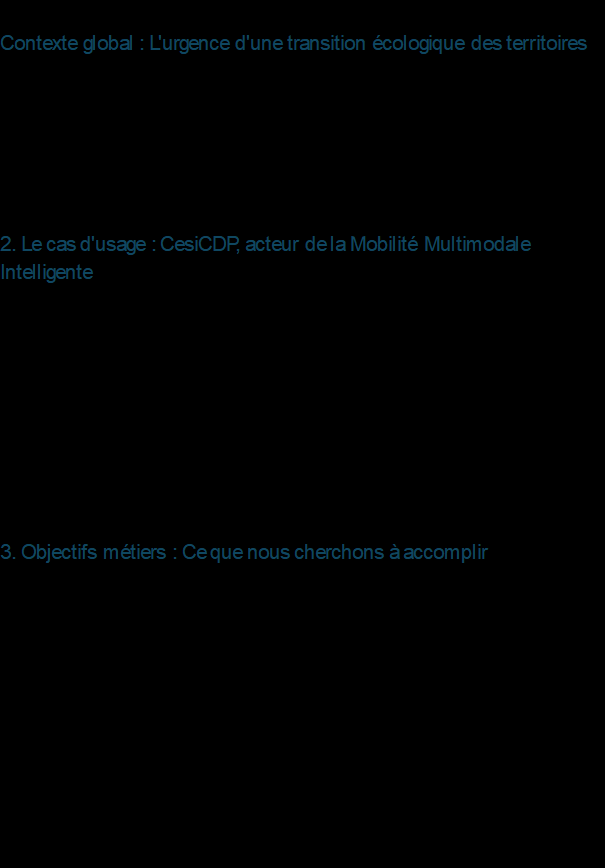

### 2. Le cas d'usage : CesiCDP, acteur de la Mobilité Multimodale Intelligente
Notre structure, CesiCDP, s'est imposée comme un partenaire de confiance et un acteur d'avant-garde dans le domaine de la Mobilité Multimodale Intelligente. Forts de nombreuses études réalisées avec nos partenaires, nous avons identifié que si les nouvelles technologies de transport offrent des perspectives prometteuses (véhicules moins polluants, capteurs connectés), elles exigent en retour une optimisation sans faille de la gestion des ressources.

### 3. Objectifs métiers : Ce que nous cherchons à accomplir
En réponse à l'appel de l'ADEME, notre objectif est de concevoir un outil d'aide à la décision algorithmique capable de révolutionner la planification des tournées de véhicules.
Notre mission est la suivante : Étant donné un point de départ (un entrepôt) et un ensemble de lieux à visiter (des villes, des points de livraison ou de collecte), nous voulons calculer l'itinéraire parfait. Cet itinéraire doit permettre de visiter tous les points requis et de revenir au point de départ en minimisant le temps de trajet total et la distance parcourue.
Les retombées directes de cette optimisation sont :
#### •	Environnementales : Une réduction drastique de l'empreinte carbone et des émissions de polluants locaux grâce à la diminution du kilométrage.
#### •	Économiques : Une baisse des coûts opérationnels (carburant, usure des véhicules).
#### •	Sociétales : Une diminution des nuisances sonores et de la congestion du trafic pour les riverains.


### 4. Justification des contraintes : Rapprocher le modèle de la réalité du terrain
Le problème classique des tournées de véhicules pose des bases mathématiques solides, mais il reste trop théorique pour capturer la complexité des opérations logistiques de CesiCDP. C'est pourquoi nous avons enrichi notre modèle avec deux contraintes fondamentales :
#### •	Contrainte 1 : Les fenêtres temporelles
##### o	Justification : Dans le monde réel, un point de livraison ou de collecte n'est presque jamais accessible 24h/24. Qu'il s'agisse d'une entreprise avec des horaires d'ouverture stricts, d'un commerce de centre-ville exigeant une livraison matinale avant l'arrivée des clients, ou d'une réglementation municipale limitant les horaires de ramassage des déchets pour éviter les nuisances sonores, le temps est une donnée inflexible. Intégrer des "fenêtres de tir" garantit que notre algorithme propose des tournées non seulement optimisées en distance, mais surtout réalistes des niveaux de service attendus par les acteurs locaux.
#### •	Contrainte 2 : Coûts et restrictions de passage sur certaines infrastructures
##### o	Justification : Un réseau routier n'est jamais figé et toutes les routes ne se valent pas. Un itinéraire mathématiquement idéal sur le papier peut s'avérer catastrophique sur le terrain : travaux en cours, route temporairement bloquée, ou pont interdit aux véhicules de certain gabarit. De plus, avec l'accélération de la transition écologique (un enjeu fort pour l'ADEME), les collectivités déploient des Zones à Faibles Émissions (ZFE) ou des péages urbains qui pénalisent ou interdisent l'accès à certaines artères. En permettant d'attribuer des surcoûts ou des interdictions strictes à certains tronçons, notre modèle devient robuste.


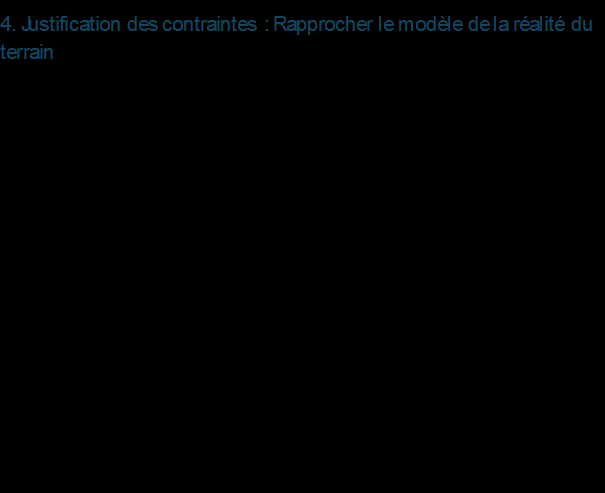
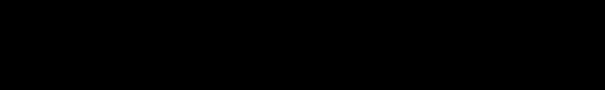

# Section 2 : État de l'art

## 1. Le Problème du Voyageur de Commerce (TSP) et ses variantes

Le problème d'optimisation des tournées de véhicules est l'un des sujets les plus étudiés en Recherche Opérationnelle. Son histoire remonte à 1959, lorsque **Dantzig et Ramser** ont formalisé pour la première fois le problème de routage de véhicules (*Vehicle Routing Problem*, VRP) dans leur article fondateur *"The Truck Dispatching Problem"*. Ils y proposaient une modélisation linéaire du problème et une méthode de résolution approchée basée sur la programmation linéaire. C'est cette publication qui a posé les premières briques mathématiques du domaine dans lequel s'inscrit notre projet.

 Ci-dessous une figure ilustrant une des solutions d'un problème de tournées de véhicule avec un dépôt central et 3 véhicules disponibles.

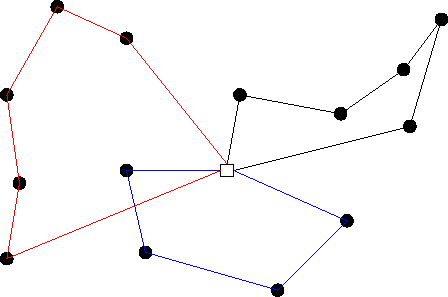

Cinq ans plus tard en 1964, **Clarke et Wright** ont introduit le célèbre algorithme des "économies" (*Savings Algorithm*), une heuristique de construction qui reste aujourd'hui encore une référence pédagogique et pratique. L'idée est simple : partir d'une configuration initiale où chaque client est servi par son propre véhicule puis fusionner itérativement les routes en calculant le "gain" réalisé à chaque fusion. Cette méthode qui est simple à implémenter et très rapide en termes de temps de calcul a ouvert la voie à des décennies de recherche sur les heuristiques de routage.

Le **Problème du Voyageur de Commerce (TSP)** qui est la variante à véhicule unique du VRP a lui aussi fait l'objet d'une attention considérable. Dans sa version de base, le TSP cherche un cycle Hamiltonien de coût minimal dans un graphe complet. L'ajout de contraintes temporelles a naturellement conduit à la formulation du **TSPTW** (*Traveling Salesman Problem with Time Windows*) notre problème cible : chaque client doit désormais être visité dans un créneau horaire prédéfini.

L'image représente un exemple du TSP avec un itinéraire qui doit commencer et se terminer à Boston.
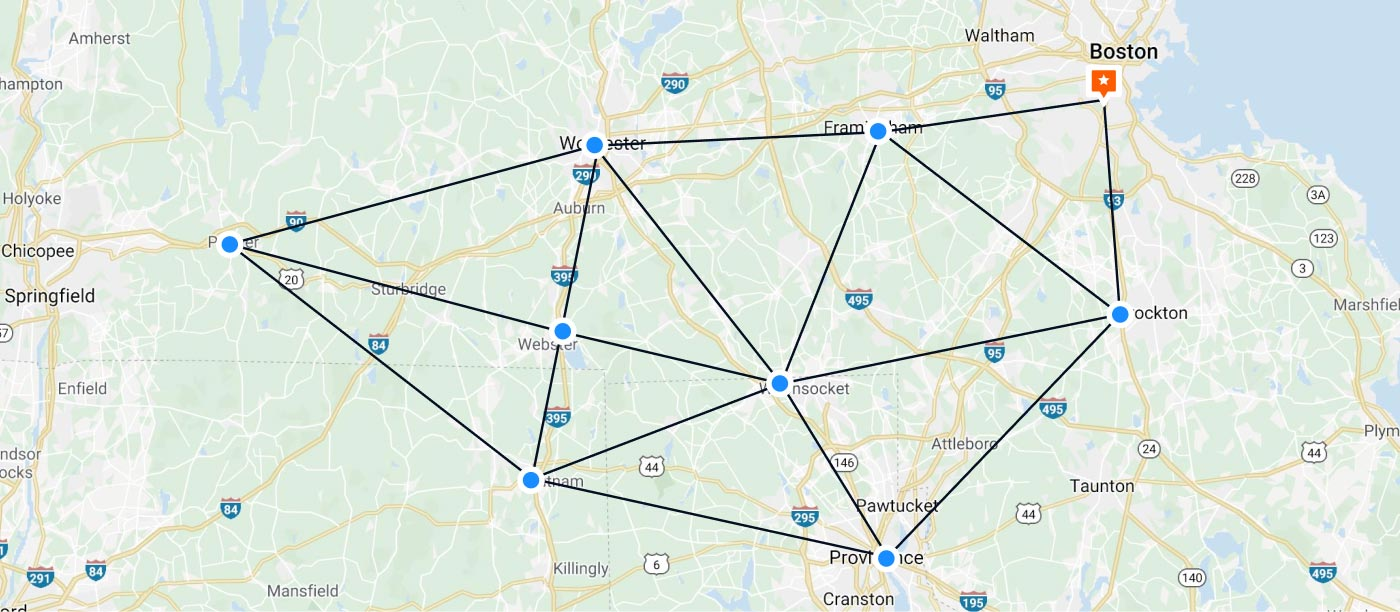

Il est important de distinguer le TSPTW du **VRPTW** (*Vehicle Routing Problem with Time Windows*) : le VRPTW généralise le problème à une flotte de véhicules tandis que le TSPTW se restreint à un véhicule unique. Notre modèle s'inscrit dans le cadre de CesiCDP avec un seul véhicule de tournée et se positionne donc directement sur le TSPTW. **Savelsbergh (1985)** a montré que même la simple vérification de la faisabilité d'une solution au TSPTW (trouver une solution valide sans chercher l'optimalité) est un problème NP-complet en lui-même ce qui souligne la difficulté du problème.

## 2. Méthodes exactes

Les méthodes exactes cherchent à trouver la solution optimale garantie de manière mathématique. Plusieurs approches ont été développées et appliquées au TSPTW et à ses variantes.

#### • La Programmation Linéaire en Nombres Entiers (PLNE) avec Branch-and-Bound
##### o L'approche la plus directe consiste à modéliser le problème sous forme d'un programme linéaire mixte en nombres entiers (comme nous l'avons fait en Section 3) et à le résoudre grâce à des solveurs comme **CPLEX** ou **Gurobi**. Ces solveurs utilisent la technique du *Branch-and-Bound* (séparation et évaluation) pour explorer l'arbre des solutions. **Christofides et Baker** ont développé des algorithmes de ce type capables de résoudre des instances allant jusqu'à 50 nœuds avec des fenêtres temporelles de taille modérée. La limite fondamentale de ces méthodes reste leur passage à l'échelle : la taille de l'arbre de recherche explose avec le nombre de clients rendant la résolution exacte irréaliste au-delà de quelques dizaines de nœuds.

#### • La Programmation Dynamique
##### o **Dumas et al. (1995)** ont proposé un algorithme exact basé sur la programmation dynamique pour résoudre le TSPTW de manière optimale. Cet algorithme est capable de gérer des instances allant jusqu'à 200 clients et constitue l'une des références de l'état de l'art pour les méthodes exactes sur ce problème. Il repose sur une représentation par états des solutions partielles permettant d'éviter l'exploration d'une grande partie de l'espace de recherche grâce à la propagation des contraintes temporelles.

Ces deux familles de méthodes exactes partagent la même limite : elles ne passent pas à l'échelle d'un réseau territorial réel de 50, 100 ou plusieurs centaines de points de livraison. C'est précisément pourquoi les chercheurs se sont tournés vers des méthodes approchées.

## 3. Heuristiques et Méta-heuristiques

Face à l'impossibilité pratique des méthodes exactes sur des instances réalistes, deux grandes familles d'algorithmes approchés se sont imposées dans la littérature.

#### • Les heuristiques de construction
##### o L'heuristique du **Plus Proche Voisin** (*Nearest Neighbor*) est l'approche la plus simple : le véhicule part du dépôt et se dirige à chaque étape vers le client non encore visité le plus proche qui respecte sa fenêtre temporelle. Bien que sous-optimale, elle produit une solution initiale raisonnable en un temps quasi instantané. **Gendreau et al. (1998)** ont proposé une heuristique d'insertion généralisée pour le TSPTW qui améliore ce principe en insérant les clients dans la tournée à la position qui minimise l'augmentation du coût total en respectant l'ensemble des contraintes temporelles. Ces travaux constituent une référence directe pour notre implémentation heuristique.

#### • Les méta-heuristiques
##### o La **Recherche Tabou** (*Tabu Search*), introduite par **Glover (1986-1990)** est l'une des méta-heuristiques les plus efficaces pour le routage. Elle explore le voisinage de la solution courante en s'autorisant des dégradations temporaires mais en maintenant une liste de mouvements "tabous" pour éviter de revisiter des solutions récemment explorées. Cette mémoire à court terme est le mécanisme qui permet à l'algorithme d'échapper aux optimums locaux.

##### o Le **Recuit Simulé** (*Simulated Annealing*), introduit par **Kirkpatrick et al. (1983)**, s'inspire du processus physique de refroidissement des métaux. À haute "température" (en début d'exécution) l'algorithme accepte fréquemment des solutions dégradées pour explorer largement l'espace des solutions. Au fur et à mesure que la température diminue, les critères d'acceptation se resserrent et l'algorithme converge vers une solution de qualité. Appliqué au TSPTW, le recuit simulé s'est révélé particulièrement efficace pour les instances où les fenêtres temporelles sont larges.

##### o Les **Algorithmes Génétiques**, dont les bases ont été posées par **Holland (1975)**, opèrent sur une population de solutions candidates. À chaque génération, les meilleures solutions sont sélectionnées, croisées et mutées pour produire une nouvelle génération. **Potvin et Bengio (1996)** ont appliqué avec succès des algorithmes génétiques au VRPTW en s'appuyant sur les instances de benchmark proposées par Solomon, produisant des résultats compétitifs par rapport aux méthodes exactes sur des instances de taille moyenne.

# Section 3 : Analyse de la Complexité Théorique du Problème

# 1. Pourquoi évaluer la difficulté de notre problème ?

Avant de développer des algorithmes pour optimiser les tournées de nos véhicules, il est essentiel de comprendre la nature mathématique du problème auquel nous sommes confrontés. En informatique théorique, tous les problèmes ne se valent pas, certains peuvent être résolus rapidement, quelle que soit leur taille, tandis que d'autres voient leur temps de résolution exploser dès que l'on ajoute quelques variables.

Dans le cadre de cet appel à projets de l'ADEME, nous devons traiter des réseaux de transport à l'échelle de territoires entiers. Notre modèle doit gérer des contraintes temporelles strictes (les fenêtres de livraison de chaque client) et s'adapter dynamiquement aux restrictions du réseau routier (zones à faibles émissions, routes barrées). L'objectif de cette section est de démontrer formellement la complexité de ce problème pour justifier nos futurs choix algorithmiques. [1]

## 2. Énoncé du Théorème

### A. Le Problème de Décision

Le problème d'optimisation de tournée avec fenêtres temporelles et restrictions de passage (que nous nommerons TSPTW-Restreint, pour Traveling Salesperson Problem with Time Windows) est un problème NP-difficile.

En termes simples, qualifier un problème de "NP-difficile" signifie qu'il n'existe à ce jour aucun algorithme connu capable de trouver la solution absolument parfaite en un temps d'exécution raisonnable (polynomial) pour toutes les instances du problème.
Transformons notre problème d'optimisation (trouver le trajet le plus court) en un problème de décision.La question que l'on pose à l'algorithme devient :
- "Étant donné notre réseau de villes (incluant des routes potentiellement interdites ou restreintes), notre véhicule unique, et nos contraintes de créneaux horaires pour chaque client, existe-t-il une tournée dont le coût total (en temps ou en distance) est inférieur ou égal à une valeur cible $C$ ?"

### B. L'Algorithme de Vérification

```
Fonction VerifierSolution(Route, MatriceCouts, FenetresTemps, AretesInterdites, Cible_C):
    CoutTotal = 0
    TempsActuel = 0
    VillesLivrees = Liste vide
    NbVilles = longueur(Route) - 2 // On exclut le dépôt de départ/arrivée

    // Parcours de la route étape par étape
    Pour chaque etape i de 0 à NbVilles:
        VilleActuelle = Route[i]
        VilleSuivante = Route[i+1]

        // Vérification 1 : Restriction de passage (ZFE ou route barrée)
        Si (VilleActuelle, VilleSuivante) est dans AretesInterdites:
            Retourner FAUX (Emprunt d'une route interdite)

        // Trajet vers la ville suivante
        TempsDeTrajet = MatriceCouts[VilleActuelle][VilleSuivante]
        TempsActuel = TempsActuel + TempsDeTrajet
        CoutTotal = CoutTotal + TempsDeTrajet

        // Vérification 2 : Fenêtre temporelle de la ville suivante
        HeureOuverture = FenetresTemps[VilleSuivante].Debut
        HeureFermeture = FenetresTemps[VilleSuivante].Fin

        Si TempsActuel > HeureFermeture:
            Retourner FAUX (Livraison en retard, client fermé)

        Si TempsActuel < HeureOuverture:
            // Le livreur est en avance, il doit attendre l'ouverture
            TempsActuel = HeureOuverture

        Ajouter VilleSuivante à VillesLivrees

    // Vérification 3 : Toutes les villes ont-elles été livrées ?
    Si VillesLivrees contient des doublons ou s'il manque des villes:
        Retourner FAUX (Erreur de livraison)

    // Vérification 4 : Le coût total respecte-t-il la cible ?
    Si CoutTotal > Cible_C:
        Retourner FAUX (Objectif non atteint)

    Retourner VRAI (Solution valide)
```

À la lecture de notre algorithme de vérification, on observe une unique boucle principale qui parcourt les étapes de la route du véhicule.Puisque dans une solution valide, le véhicule visite exactement une fois chaque client, cette boucle s'exécutera exactement $n$ fois (où $n$ est le nombre total de clients à livrer sur le territoire).

À l'intérieur de cette boucle, l'algorithme n'effectue que des opérations simples et instantanées :
- Des additions (pour cumuler le temps de trajet et le coût total).
- Des comparaisons conditionnelles (pour vérifier si l'heure d'arrivée respecte les fenêtres temporelles et si la route est autorisée).
- L'ajout de la ville visitée dans une structure de données (comme un set en Python) pour s'assurer par la suite qu'il n'y a aucun doublon.

En informatique, la lecture d'une variable ou l'accès à une table de hachage s'exécute en un temps constant, noté $\mathcal{O}(1)$. Puisque notre algorithme exécute un nombre d'opérations constantes de manière strictement proportionnelle au nombre de villes ($n \times \mathcal{O}(1)$), son temps d'exécution global grandit de façon purement linéaire.La complexité de notre algorithme de vérification est donc bien en $\mathcal{O}(n)$.
Cette capacité à vérifier une solution en temps polynomial est la condition stricte qui prouve que notre problème appartient formellement à la classe NP.

_

Par conséquent, puisque notre programme effectue un nombre limité d'opérations instantanées exactement $n$ fois, le temps de réponse total de notre algorithme de vérification grandira de manière purement proportionnelle au nombre de clients. C'est la définition même d'une complexité linéaire en $O(n)$.

## C. Preuve de NP-Complétude du Problème du Voyageur de Commerce (TSP)

Avant d'analyser notre problème spécifique de livraison, nous devons prouver la complexité de son socle fondamental : le Problème du Voyageur de Commerce (TSP) sur un graphe incomplet.

Pour prouver qu'un problème de décision est **NP-Complet**, la démarche mathématique exige de démontrer deux choses :
1. Qu'il appartient à la classe **NP** (on peut vérifier une solution rapidement).
2. Qu'il est **NP-difficile** (on peut y réduire un problème NP-Complet déjà connu en un temps polynomial).

### Étape 1 : Le TSP appartient à la classe NP

**Problème de décision du TSP :** Étant donné un graphe $G=(V,E)$ pondéré et un entier $k$, existe-t-il un cycle simple passant par tous les sommets de $V$ exactement une fois, avec un coût total inférieur ou égal à $k$ ?

**Algorithme de vérification :**
Si l'on nous donne un cycle candidat (une liste de sommets), nous pouvons vérifier s'il est valide en :
1. Comptant le nombre de sommets visités pour s'assurer qu'ils y sont tous, sans doublons.
2. Vérifiant que chaque arête empruntée existe bien dans l'ensemble $E$.
3. Faisant la somme des poids de ces arêtes et en vérifiant qu'elle est $\le k$.

Ce parcours ne nécessite qu'une seule boucle sur les $n$ sommets du graphe. Le temps de vérification est donc de complexité linéaire $\mathcal{O}(n)$, ce qui est un temps polynomial. Le TSP appartient donc formellement à la classe **NP**.

### Étape 2 : Le TSP est NP-difficile (Preuve par réduction)

Pour prouver la NP-difficulté, nous allons réduire un problème célèbre déjà prouvé comme étant NP-Complet : le **Problème du Cycle Hamiltonien (HC)**, vers notre problème TSP.

**Rappel du Cycle Hamiltonien (HC) :** Étant donné un graphe non pondéré $G=(V,E)$, existe-t-il un cycle simple passant par chaque sommet exactement une fois ?

**La Transformation (Réduction) :**
À partir d'une instance quelconque du problème HC (un graphe $G=(V,E)$ de $n$ sommets), construisons une instance du TSP :
1. Prenons le même ensemble de sommets $V$.
2. Créons un graphe complet $G'=(V,E')$ où toutes les paires de sommets sont reliées par une arête.
3. Attribuons les coûts suivants aux arêtes de $G'$ :
   - Si l'arête $(u,v)$ existe dans le graphe d'origine $G$, son coût est de $1$.
   - Si l'arête $(u,v)$ n'existe pas dans le graphe d'origine $G$, son coût est de $2$.
4. Fixons notre coût cible pour le TSP à $k = n$.

Cette transformation se fait en parcourant les paires de sommets, soit en un temps $\mathcal{O}(n^2)$, ce qui est bien polynomial.

### Étape 3 : Équivalence des solutions

Prouvons maintenant que la solution au problème HC existe **si et seulement si** la solution au problème TSP existe :

- **Sens $\Rightarrow$ :** S'il existe un cycle Hamiltonien dans le graphe $G$, ce cycle comprend exactement $n$ arêtes. Dans notre nouveau graphe $G'$, toutes ces arêtes ont un poids de $1$. Le coût total du cycle dans $G'$ est donc de $n \times 1 = n$. La condition du TSP (coût $\le k$ avec $k=n$) est remplie.
- **Sens $\Leftarrow$ :** S'il existe une solution au TSP dans $G'$ avec un coût total $\le n$, sachant que le cycle doit obligatoirement comporter $n$ arêtes et que le coût minimum d'une arête est $1$, la seule façon d'obtenir un coût de $n$ est de n'emprunter que des arêtes de poids $1$. Par définition de notre réduction, ces arêtes de poids $1$ appartiennent toutes au graphe d'origine $G$. Donc, ce cycle est un cycle Hamiltonien valide pour $G$.

**Conclusion :** Puisque le Problème du Cycle Hamiltonien se réduit polynomialement au Problème du Voyageur de Commerce (HC $\le_p$ TSP) et que le HC est NP-Complet, **le problème de décision du TSP est  NP-Complet.**

D'une part, grâce à notre algorithme de vérification, nous avons prouvé qu'il est possible de vérifier la validité d'une solution en temps linéaire. Cette rapidité de vérification est la condition stricte pour qu'un problème décisionnel appartienne à la classe NP.

D'autre part, notre problème d'optimisation est intrinsèquement NP-difficile. Comme nous l'avons démontré par la méthode de restriction, la recherche de l'itinéraire le plus court englobe le célèbre Problème du Voyageur de Commerce (TSP). L'ajout de nos deux contraintes de terrain les fenêtres temporelles imposées par les clients et les restrictions de passage (comme les zones à faibles émissions) vient restreindre drastiquement l'espace des solutions réalisables. Trouver le bon trajet n'est plus seulement une question de distance géographique, c'est devenu un véritable casse-tête de synchronisation horaire.

Pour résumer, notre modèle logistique combine une difficulté spatiale majeure (le Problème du Voyageur de Commerce) avec des exigences temporelles strictes. Le TSP de base étant mathématiquement classé comme NP-difficile, cette version sur-contrainte de notre modèle de transport reste par extension tout aussi complexe à résoudre de manière exacte.

En pratique, cette complexité se traduit par ce qu'on appelle une "explosion combinatoire". Le nombre de tournées possibles se multiplie de façon vertigineuse à chaque fois que l'on ajoute un client. Si un ordinateur peut facilement tester toutes les options pour 10 villes, la tâche devient impossible pour une échelle territoriale réaliste de 50 points de livraison. Il y a un tel nombre de combinaisons que même les machines les plus puissantes mettraient des années à toutes les évaluer pour garantir un trajet absolument parfait.

Puisqu'une méthode de calcul exacte (la "force brute") prendrait beaucoup trop de temps, nous allons utiliser des algorithmes d'optimisation approchée (les heuristiques et métaheuristiques). L'objectif n'est plus de chercher la perfection absolue, mais d'explorer intelligemment les possibilités pour fournir une solution très performante. Cela nous permettra d'optimiser les tournées, de réduire l'impact carbone et de respecter des temps de calcul de quelques secondes, comme l'exige la réalité du terrain chez CesiCDP.

# Section 4 : Modélisation formelle du Problème de Tournée (TSPTW)

## 1. Contexte et enjeux (ADEME)

Depuis les engagements mondiaux des années 90 (Protocole de Kyoto) et face à l'urgence climatique actuelle, la réduction des émissions de gaz à effet de serre est devenue une priorité absolue. Les collectivités territoriales, accompagnées par des organismes comme l'**ADEME** (Agence de l'Environnement et de la Maîtrise de l'Énergie), cherchent activement de nouvelles solutions de mobilité intelligente.

Notre structure, **CesiCDP**, répond à cet appel à manifestation d'intérêt. L'enjeu de notre étude est de démontrer comment l'optimisation algorithmique peut réduire drastiquement l'empreinte carbone des activités de logistique (livraison, ramassage).

Pour coller au plus près de la réalité du terrain, nous avons choisi de modéliser un problème complexe intégrant deux contraintes majeures :
1. **Les fenêtres temporelles (Time Windows) :** Chaque client impose des heures strictes d'ouverture et de fermeture.
2. **Les restrictions de passage :** Le réseau routier subit des perturbations (travaux, Zones à Faibles Émissions) interdisant physiquement certaines routes.

Notre objectif est donc de modéliser mathématiquement ce problème, connu sous le nom de **TSPTW** (Traveling Salesperson Problem with Time Windows), avant d'en proposer une résolution algorithmique.
## 2. Définition du Graphe, des Paramètres et des Variables

### A. Le Graphe et les Ensembles
* **Le Graphe :** Nous définissons un graphe orienté $G = (V, A)$ où $V = \{0, 1, 2, \dots, n\}$ est l'ensemble des sommets.
* **Les Nœuds :** Le sommet $0$ représente le dépôt (point de départ et d'arrivée). Les sommets $\{1, \dots, n\}$ représentent les clients à livrer.
* **Les Arêtes :** $A$ représente l'ensemble des routes autorisées. Si une route est fermée (travaux ou zone restreinte), l'arête correspondante n'existe tout simplement pas dans $A$.

### B. Les Paramètres (Données d'entrée)
* $c_{ij}$ : le coût (ou la distance) pour aller de la ville $i$ à la ville $j$.
* $t_{ij}$ : le temps de trajet estimé pour aller de la ville $i$ à la ville $j$.
* $[e_i, l_i]$ : la fenêtre temporelle de livraison pour le client $i$.
    * $e_i$ (early) : l'heure d'ouverture (le livreur ne peut pas livrer avant).
    * $l_i$ (late) : l'heure de fermeture (le livreur ne doit absolument pas arriver après).

### C. Les Variables de Décision (Ce que l'algorithme doit trouver)
* $x_{ij} \in \{0, 1\}$ : variable binaire valant $1$ si notre véhicule emprunte directement la route allant de $i$ à $j$, et $0$ sinon.
* $T_i \ge 0$ : variable continue qui enregistre l'heure exacte de début de service du véhicule à la ville $i$.
## 3. Modélisation Mathématique

### A. La Fonction Objectif [2]
L'objectif de notre modèle est de minimiser le coût total de la tournée (distance totale ou carburant consommé).
$$\text{Min} \sum_{i \in V} \sum_{j \in V} c_{ij} x_{ij}$$

Nous calculons la somme des coûts $c_{ij}$ de tous les trajets possibles, multipliée par notre variable de décision $x_{ij}$. Puisque $x_{ij}$ vaut $1$ si la route est empruntée et $0$ sinon, l'équation ne calculera que le coût des routes réellement utilisées par le véhicule. À noter que si une route est interdite (zone à faibles émissions, travaux), son coût $c_{ij}$ est défini à $+\infty$, ce qui empêchera mathématiquement toute solution optimale de l'emprunter.

### B. Contraintes de Parcours
Chaque client doit être visité exactement une fois.
Le véhicule doit arriver une fois chez le client $j$ :
$$\sum_{i \in V, i \neq j} x_{ij} = 1 \quad \forall j \in \{1, \dots, n\}$$

Le véhicule doit repartir une fois du client $i$ :
$$\sum_{j \in V, j \neq i} x_{ij} = 1 \quad \forall i \in \{1, \dots, n\}$$

Le véhicule doit quitter le dépôt ($0$) et y revenir à la fin de sa tournée :
$$\sum_{j=1}^{n} x_{0j} = 1 \quad \text{et} \quad \sum_{i=1}^{n} x_{i0} = 1$$

### C. Contraintes de Fenêtres Temporelles et Sous-tournées
La gestion du temps relie nos variables de parcours $x_{ij}$ à nos variables de temps $T_i$ grâce à la méthode du "Big-M" (où $M$ est une constante suffisamment grande). Si le véhicule se déplace de $i$ à $j$, l'heure d'arrivée $T_j$ doit être cohérente avec le temps de trajet :
$$T_j \ge T_i + t_{ij} - M(1 - x_{ij}) \quad \forall i \in V, \forall j \in \{1, \dots, n\}, i \neq j$$
*Note : Cette inéquation permet également d'éliminer les sous-tournées illogiques.*

Si le véhicule ne va pas de $i$ à $j$ ($x_{ij} = 0$), le terme $-M$ rend l'inégalité triviale et désactive la contrainte. En revanche, si le véhicule emprunte bien cette route ($x_{ij} = 1$), l'équation devient $T_i + t_{ij} \le T_j$. L'heure d'arrivée $T_j$ intègre donc bien le temps de trajet $t_{ij}$.
Cette contrainte est efficace car elle empêche également la formation de "sous-tours" (le véhicule qui tournerait en rond sur 3 villes sans passer par le dépôt). Le temps $T$ ne pouvant qu'augmenter, il est mathématiquement impossible de créer une boucle fermée infinie.


Enfin, le service doit impérativement s'effectuer dans la fenêtre temporelle du client :
$$e_i \le T_i \le l_i \quad \forall i \in \{1, \dots, n\}$$

## 4. Domaine de définition des variables

Enfin, nous figeons la nature mathématique de nos variables de décision.

$x_{ij} \in \{0, 1\} \quad \forall i, j \in V$
$T_i \ge 0 \quad \forall i \in V$

Les trajets sont des choix binaires (OUI ou NON), et le temps est une valeur continue strictement positive.





# Section 5 : Choix des méthodes de résolution

Face à la complexité NP-difficile du problème de tournées de véhicules, il n'existe pas d'algorithme capable de trouver la solution parfaite instantanément pour un grand nombre de villes.
Pour répondre aux exigences de l'ADEME et fournir un outil complet à CesiCDP, nous avons fait le choix stratégique d'implémenter et de comparer trois approches algorithmiques distinctes. Cette démarche progressive nous permet d'allier rigueur mathématique, rapidité d'exécution et performance sur des données à grande échelle. [3]
### 1. La méthode exacte : Programmation Linéaire (PL) avec solveur
Le principe : Cette méthode consiste à traduire rigoureusement notre problème sous forme d'équations mathématiques. Nous utilisons ensuite un solveur mathématique pour explorer l'arbre des solutions et trouver le meilleur possible.
Pourquoi ce choix ?
##### •    La garantie de l'optimum global : C'est la seule méthode qui prouve mathématiquement que la solution trouvée est la meilleure absolue.
##### •    L'établissement d'une référence : Sur des instances de petite taille (quelques villes), le solveur nous donnera la solution parfaite.
### 2. L'algorithme heuristique
Le principe : Plutôt que de chercher la solution parfaite, elle construit une solution "étape par étape" en utilisant des règles logiques simples (par exemple l'algorithme du "plus proche voisin", où le camion va systématiquement vers la ville non visitée la plus proche qui respecte les contraintes de temps).
Pourquoi ce choix ?
##### •    La réactivité : Le temps de calcul est quasi instantané. Dans un contexte de logistique urbaine perturbée (un camion tombe en panne ou une route est soudainement bloquée), cette méthode permet de recalculer une tournée valide.
##### •    L'initialisation : L'heuristique simple produit une solution de départ tout à fait acceptable. Elle servira de base de travail pour des algorithmes d'optimisation plus avancés.
### 3. L'algorithme méta-heuristique
Le principe : Les méta-heuristiques comme les algorithmes génétiques, la recherche tabou ou le recuit simulé sont des méthodes d'optimisation avancées. Elles prennent une solution de départ et l'améliorent itérativement en explorant l'espace des solutions, tout en s'autorisant parfois des dégradations temporaires (diversification) pour éviter d'être bloquées dans des optimums locaux.
Pourquoi ce choix ?
##### •    Le compromis idéal pour le monde réel : C'est la méthode reine en Recherche Opérationnelle pour les problèmes logistiques. Elle ne garantit pas la solution parfaite à 100%, mais elle est capable de trouver des solutions excellentes sur des très grands réseaux, dans un temps imparti raisonnable.
##### •    Adaptabilité aux contraintes complexes : Les méta-heuristiques gèrent de manière très fluide l'ajout de pénalités liées aux contraintes métiers de CesiCDP. C'est cet algorithme qui constituera le moteur principal de la solution finale proposée à l'ADEME.

# Section 6 : Implémentation

In [13]:
import math
import random
import time
import matplotlib.pyplot as plt
import pulp

**Explication :** Cette première cellule importe les bibliothèques nécessaires au projet :
- `math` et `random` : Pour la génération du territoire et des lois de probabilité du Recuit Simulé.
- `time` : Pour chronométrer nos algorithmes et comparer leurs performances.
- `matplotlib.pyplot` : Pour la visualisation graphique des tournées (fondamental pour vérifier la cohérence spatiale).
- `pulp` : La bibliothèque de modélisation mathématique qui nous servira pour notre solveur exact (Programme Linéaire).

In [14]:
class Ville:
    def __init__(self, index, x, y, heure_ouverture=0, heure_fermeture=9999):
        self.index = index
        self.x = x
        self.y = y
        self.heure_ouverture = heure_ouverture
        self.heure_fermeture = heure_fermeture

    def __str__(self):
        if self.index == 0:
            return f"Dépôt (x:{self.x}, y:{self.y})"
        return f"Client {self.index} | Pos:({self.x}, {self.y}) | Fenêtre: [{self.heure_ouverture} - {self.heure_fermeture}]"

class Reseau:
    def __init__(self, nb_villes=6, largeur=500, hauteur=500, proba_route_barree=0.02, min_fenetre=1500, max_fenetre=4000):
        self.nb_villes = nb_villes
        self.largeur = largeur
        self.hauteur = hauteur
        self.proba_route_barree = proba_route_barree

        self.min_fenetre = min_fenetre
        self.max_fenetre = max_fenetre

        self.villes = []
        self.matrice_distances = []

    def generer_villes(self):
        depot = Ville(0, self.largeur // 2, self.hauteur // 2, 0, 99999)
        self.villes.append(depot)
        for i in range(1, self.nb_villes):
            x = random.randint(0, self.largeur)
            y = random.randint(0, self.hauteur)

            dist_depuis_depot = math.sqrt((x - depot.x) ** 2 + (y - depot.y) ** 2)
            ouverture = int(dist_depuis_depot) + random.randint(0, 100)

            largeur_fenetre = random.randint(self.min_fenetre, self.max_fenetre)
            fermeture = ouverture + largeur_fenetre

            client = Ville(i, x, y, ouverture, fermeture)
            self.villes.append(client)

    def calculer_matrice(self):
        self.matrice_distances = []
        for i in range(self.nb_villes):
            ligne = []
            for j in range(self.nb_villes):
                if i == j:
                    ligne.append(0)
                else:
                    ville1 = self.villes[i]
                    ville2 = self.villes[j]
                    dist = math.sqrt((ville1.x - ville2.x) ** 2 + (ville1.y - ville2.y) ** 2)
                    if i != 0 and j != 0 and random.random() < self.proba_route_barree:
                        ligne.append(float('inf'))
                    else:
                        ligne.append(round(dist, 2))
            self.matrice_distances.append(ligne)

    def afficher_reseau(self):
        fig, ax = plt.subplots(figsize=(12, 8))
        fig.patch.set_facecolor('white')
        ax.set_facecolor('white')
        for i in range(self.nb_villes):
            for j in range(self.nb_villes):
                if i != j:
                    if self.matrice_distances[i][j] == float('inf'):
                        plt.plot([self.villes[i].x, self.villes[j].x], [self.villes[i].y, self.villes[j].y], color='red', linestyle='--', linewidth=1, alpha=0.3)
                    else:
                        plt.plot([self.villes[i].x, self.villes[j].x], [self.villes[i].y, self.villes[j].y], color='gray', linestyle='-', linewidth=0.5, alpha=0.1)

        depot = self.villes[0]
        clients = self.villes[1:]
        plt.scatter([v.x for v in clients], [v.y for v in clients], c='dodgerblue', s=80, zorder=5, label='Clients')
        plt.scatter(depot.x, depot.y, c='crimson', marker='s', s=120, zorder=5, label='Dépôt')
        plt.title(f"Réseau CesiCDP ({self.nb_villes-1} clients)", weight='bold')
        plt.legend()
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.show()

    def afficher_solution(self, chemin, cout, titre="Solution"):
        fig, ax = plt.subplots(figsize=(12, 8))
        fig.patch.set_facecolor('white')
        ax.set_facecolor('white')
        for i in range(self.nb_villes):
            for j in range(self.nb_villes):
                if i != j:
                    if self.matrice_distances[i][j] == float('inf'):
                        plt.plot([self.villes[i].x, self.villes[j].x],
                                 [self.villes[i].y, self.villes[j].y],
                                 color='red', linestyle='--', linewidth=1, alpha=0.3)
                    else:
                        plt.plot([self.villes[i].x, self.villes[j].x],
                                 [self.villes[i].y, self.villes[j].y],
                                 color='gray', linestyle='-', linewidth=0.5, alpha=0.1)

        for k in range(len(chemin) - 1):
            a, b = chemin[k], chemin[k + 1]
            va, vb = self.villes[a], self.villes[b]
            plt.annotate("", xy=(vb.x, vb.y), xytext=(va.x, va.y),
                         arrowprops=dict(arrowstyle="->", color="limegreen", lw=2.5))

        depot = self.villes[0]
        clients = self.villes[1:]
        plt.scatter([v.x for v in clients], [v.y for v in clients], c='dodgerblue', s=100, zorder=5, label='Clients')
        plt.scatter(depot.x, depot.y, c='crimson', marker='s', s=150, zorder=5, label='Dépôt')

        for v in self.villes:
            if v.index == 0:
                texte = "Dépôt"
            else:
                texte = f"C{v.index}\n[{v.heure_ouverture}-{v.heure_fermeture}]"
            plt.annotate(texte, (v.x + 8, v.y + 8), fontsize=9, color='darkslategray', weight='bold',
                         bbox=dict(facecolor='white', edgecolor='none', alpha=0.7), zorder=10)

        plt.title(f"{titre} — Coût : {cout:.1f}", fontsize=14, weight='bold')

        import matplotlib.lines as mlines
        ligne_ok = mlines.Line2D([], [], color='gray', linewidth=1, label='Route Autorisée')
        ligne_ko = mlines.Line2D([], [], color='red', linestyle='--', linewidth=1, label='Route Interdite')
        ligne_sol = mlines.Line2D([], [], color='limegreen', linewidth=2.5, label='Trajet Solution')
        plt.legend(handles=[ligne_sol, ligne_ok, ligne_ko], loc='upper right')

        plt.grid(True, linestyle=':', alpha=0.5)
        plt.tight_layout()
        plt.show()

**Explication : Modélisation de l'Environnement** Pour que nos algorithmes puissent fonctionner, nous avons besoin d'un environnement réaliste. La classe `Reseau` gère la génération des villes en liant intelligemment la fenêtre de temps à la distance géographique (pour éviter de générer des cartes mathématiquement insolubles) et intègre l'apparition de routes barrées pour simuler les aléas du trafic (TSPTW-Restreint).

In [15]:
def preparer_donnees_pulp(reseau):
    """Adaptateur : Formate les données du Réseau pour le solveur PuLP."""
    graph = {}
    routes_interdites = set()
    for i in range(reseau.nb_villes):
        graph[i] = {}
        for j in range(reseau.nb_villes):
            if i != j:
                dist = reseau.matrice_distances[i][j]
                if dist == float('inf'):
                    graph[i][j] = 99999
                    routes_interdites.add((i, j))
                else:
                    graph[i][j] = dist

    fenetres_temps = {v.index: (v.heure_ouverture, v.heure_fermeture) for v in reseau.villes}
    fenetres_temps[0] = (0, 99999)
    return graph, fenetres_temps, routes_interdites


def solveur_tsp_pulp(graph, fenetres_temps, routes_interdites, depart=0):
    villes = list(graph.keys())
    n = len(villes)
    modele = pulp.LpProblem("TSP_Contraint", pulp.LpMinimize)

    x = pulp.LpVariable.dicts("x", (villes, villes), cat="Binary")
    temps = pulp.LpVariable.dicts("temps", villes, lowBound=0)

    modele += pulp.lpSum(graph[i][j] * x[i][j] for i in villes for j in villes if i != j)

    for i in villes:
        modele += pulp.lpSum(x[i][j] for j in villes if i != j) == 1
        modele += pulp.lpSum(x[j][i] for j in villes if i != j) == 1

    for (i, j) in routes_interdites:
        modele += x[i][j] == 0

    u = pulp.LpVariable.dicts("ordre", villes, lowBound=0, upBound=n)
    for i in villes:
        for j in villes:
            if i != j and i != depart and j != depart:
                modele += u[i] - u[j] + n * x[i][j] <= n - 1

    M = 100000
    for i in villes:
        for j in villes:
            if i != j and j != depart:
                if (i, j) not in routes_interdites:
                    modele += temps[j] >= temps[i] + graph[i][j] - M * (1 - x[i][j])

    for i in villes:
        modele += temps[i] >= fenetres_temps[i][0]
        modele += temps[i] <= fenetres_temps[i][1]

    modele += temps[depart] == 0
    modele.solve(pulp.PULP_CBC_CMD(msg=0))
    statut = pulp.LpStatus[modele.status]

    if statut != 'Optimal':
        return None, float('inf'), statut

    chemin = [depart]
    courant = depart
    visite = set([depart])
    while True:
        suivant = None
        for j in villes:
            if courant != j and pulp.value(x[courant][j]) is not None and pulp.value(x[courant][j]) > 0.5:
                suivant = j
                break
        if suivant is None or suivant in visite:
            break
        chemin.append(suivant)
        visite.add(suivant)
        courant = suivant
    chemin.append(depart)

    return chemin, pulp.value(modele.objective), statut

**Explication : Méthode Exacte (Programme Linéaire)**
Ce solveur traduit notre problème en un système d'équations mathématiques. En vertu du Principe de Responsabilité Unique, les données sont extraites de l'objet `Reseau` via un adaptateur (`preparer_donnees_pulp`). Ce solveur permet d'obtenir la preuve formelle de la meilleure tournée possible. En raison de l'explosion combinatoire (problème NP-Difficile), il ne peut être exécuté que sur de petites instances.

In [16]:
def resoudre_heuristique(reseau):
    non_visites = [v for v in reseau.villes if v.index != 0]
    ville_actuelle = reseau.villes[0]
    temps_actuel = 0
    tournee = [ville_actuelle]
    distance_totale = 0

    while non_visites:
        meilleure_ville = None
        meilleur_temps_arrivee = float('inf')

        for ville_candidate in non_visites:
            dist = reseau.matrice_distances[ville_actuelle.index][ville_candidate.index]
            if dist == float('inf'): continue

            temps_arrivee_prevu = temps_actuel + dist
            temps_debut_service = max(temps_arrivee_prevu, ville_candidate.heure_ouverture)

            if temps_debut_service <= ville_candidate.heure_fermeture:
                if temps_debut_service < meilleur_temps_arrivee:
                    meilleur_temps_arrivee = temps_debut_service
                    meilleure_ville = ville_candidate

        if meilleure_ville is None:
            distance_min = float('inf')
            for ville_candidate in non_visites:
                dist = reseau.matrice_distances[ville_actuelle.index][ville_candidate.index]
                if dist < distance_min and dist != float('inf'):
                    distance_min = dist
                    meilleure_ville = ville_candidate

            if meilleure_ville is None:
                meilleure_ville = non_visites[0]
                distance_min = 99999

            meilleur_temps_arrivee = max(temps_actuel + distance_min, meilleure_ville.heure_ouverture)

        tournee.append(meilleure_ville)
        non_visites.remove(meilleure_ville)
        distance_totale += reseau.matrice_distances[ville_actuelle.index][meilleure_ville.index]
        temps_actuel = meilleur_temps_arrivee
        ville_actuelle = meilleure_ville

    # Retour au dépôt
    dist_retour = reseau.matrice_distances[ville_actuelle.index][0]
    if dist_retour == float('inf'):
        dist_retour = 99999

    tournee.append(reseau.villes[0])
    distance_totale += dist_retour
    temps_actuel += dist_retour

    return tournee, distance_totale, temps_actuel

**Explication : Algorithme Constructif (Heuristique Gloutonne)**
Cette heuristique simule le comportement humain : à chaque étape, le livreur se dirige vers le client le plus proche dont la fenêtre de temps est valide. Cet algorithme est extrêmement rapide, mais sa vision à court terme ("myope") l'empêche de trouver l'optimum global. Il servira de solution de départ pour notre Méta-heuristique.

In [17]:
def evaluer_tournee(tournee_index, reseau):
    temps_actuel, distance_totale, penalites = 0, 0, 0
    trajet_complet = tournee_index + [0]
    ville_actuelle = 0

    for prochaine_ville in trajet_complet:
        dist = reseau.matrice_distances[ville_actuelle][prochaine_ville]
        if dist == float('inf'):
            penalites += 100000
            dist = 0

        distance_totale += dist
        temps_actuel += dist
        if prochaine_ville != 0:
            client = reseau.villes[prochaine_ville]
            if temps_actuel < client.heure_ouverture:
                temps_actuel = client.heure_ouverture
            elif temps_actuel > client.heure_fermeture:
                penalites += (temps_actuel - client.heure_fermeture) * 100
        ville_actuelle = prochaine_ville

    return distance_totale + penalites, distance_totale, penalites

def generer_voisin(tournee_actuelle):
    voisin = tournee_actuelle.copy()
    i, j = random.sample(range(len(voisin)), 2)
    voisin[i], voisin[j] = voisin[j], voisin[i]
    return voisin

def recuit_simule(reseau, temp_initiale=1000.0, taux_refroidissement=0.999, temp_finale=0.1):
    # On appelle le Glouton pour démarrer intelligemment
    tournee_objets, _, _ = resoudre_heuristique(reseau)

    if tournee_objets is None:
        # Si le Glouton échoue, on part au hasard
        tournee_actuelle = list(range(1, reseau.nb_villes))
        random.shuffle(tournee_actuelle)
    else:
        # On extrait uniquement les index des clients (sans les dépôts de début/fin)
        tournee_actuelle = [v.index for v in tournee_objets[1:-1]]

    cout_actuel, _, _ = evaluer_tournee(tournee_actuelle, reseau)
    meilleure_tournee, meilleur_cout = tournee_actuelle.copy(), cout_actuel
    temperature = temp_initiale

    while temperature > temp_finale:
        voisin = generer_voisin(tournee_actuelle)
        cout_voisin, _, _ = evaluer_tournee(voisin, reseau)
        delta = cout_voisin - cout_actuel

        if delta < 0 or random.random() < math.exp(-delta / temperature):
            tournee_actuelle, cout_actuel = voisin, cout_voisin
            if cout_actuel < meilleur_cout:
                meilleur_cout, meilleure_tournee = cout_actuel, tournee_actuelle.copy()

        temperature *= taux_refroidissement

    trajet_complet = [0] + meilleure_tournee + [0]
    return trajet_complet, meilleur_cout

def recuit_simule_multistart(reseau, temp_init, taux_refroid, nb_lancements=50):
    meilleur_cout_global = float('inf')
    meilleure_tournee_globale = None

    for _ in range(nb_lancements):
        tournee, cout = recuit_simule(reseau, temp_init, taux_refroid)
        if cout < meilleur_cout_global:
            meilleur_cout_global = cout
            meilleure_tournee_globale = tournee

    return meilleure_tournee_globale, meilleur_cout_global

**Explication : Méta-heuristique Hybride (Recuit Simulé)**
Le Recuit Simulé est notre moteur d'optimisation principal. Pour contrer l'explosion combinatoire, nous avons implémenté une **hybridation** : la solution initiale est fournie par l'Heuristique Gloutonne (0 pénalité). Le Recuit utilise ensuite son énergie pour affiner cette solution et réduire les kilomètres. Une boucle "Multi-start" englobe le tout pour garantir la robustesse.

=== GÉNÉRATION DU RÉSEAU ===


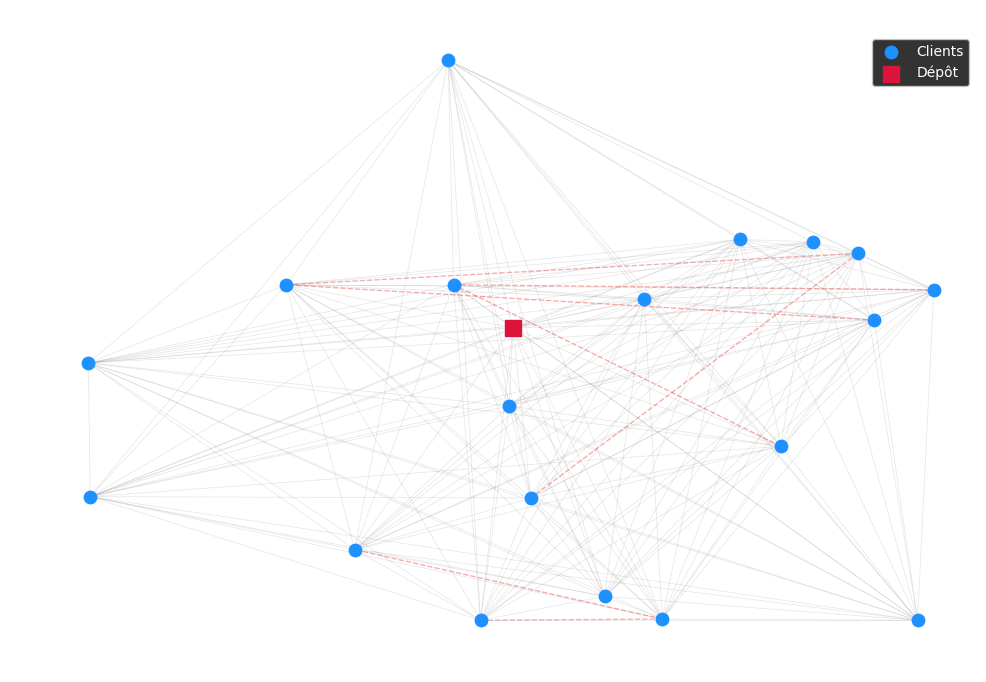


=== 1. HEURISTIQUE GLOUTONNE ===
Chemin trouvé : [0, 11, 1, 13, 5, 8, 12, 2, 9, 16, 7, 18, 4, 15, 19, 3, 6, 14, 17, 10, 0]
Distance physique (km) : 2262.01 | Temps : 0.0002 sec
Score Réel (avec pénalités) : 2262.01 (dont 0 points de retard/barrages)


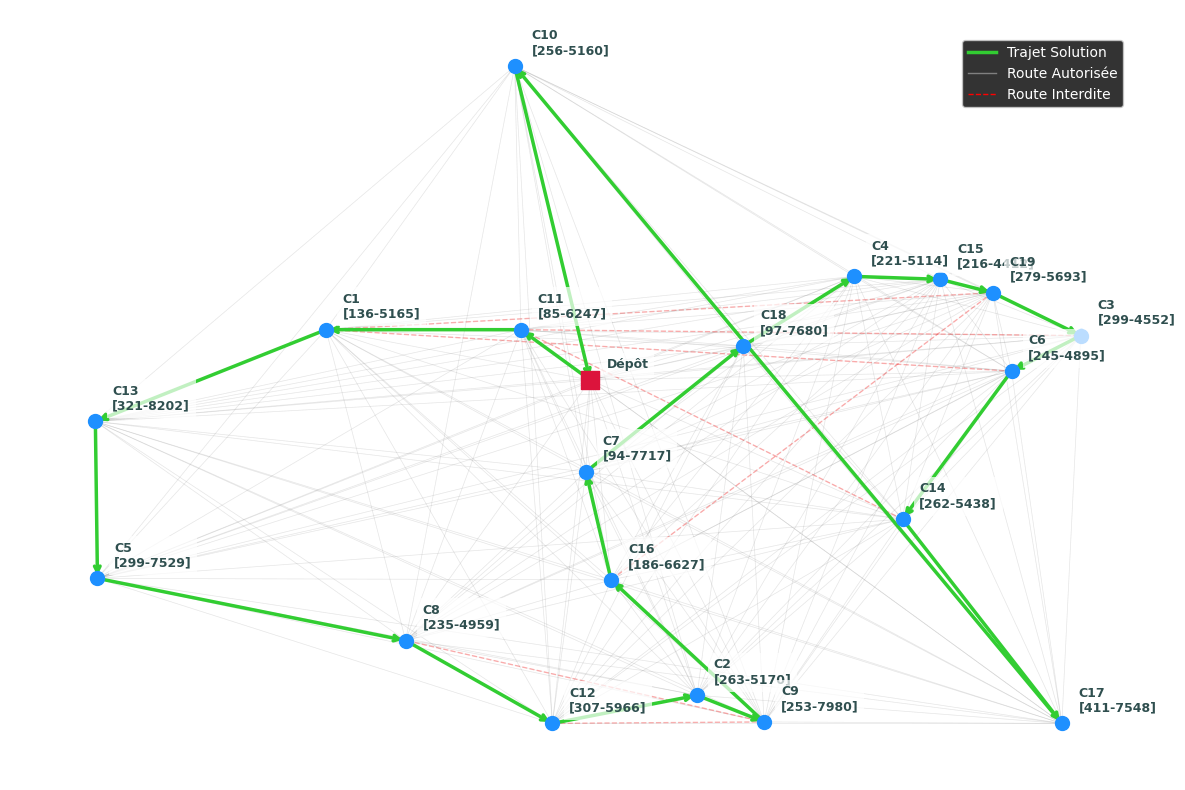


=== 2. RECUIT SIMULÉ (MULTI-START) ===
Chemin trouvé : [0, 11, 10, 1, 13, 5, 8, 12, 16, 2, 9, 17, 14, 6, 3, 19, 15, 4, 18, 7, 0]
Coût : 1943.40 | Temps : 4.9493 sec


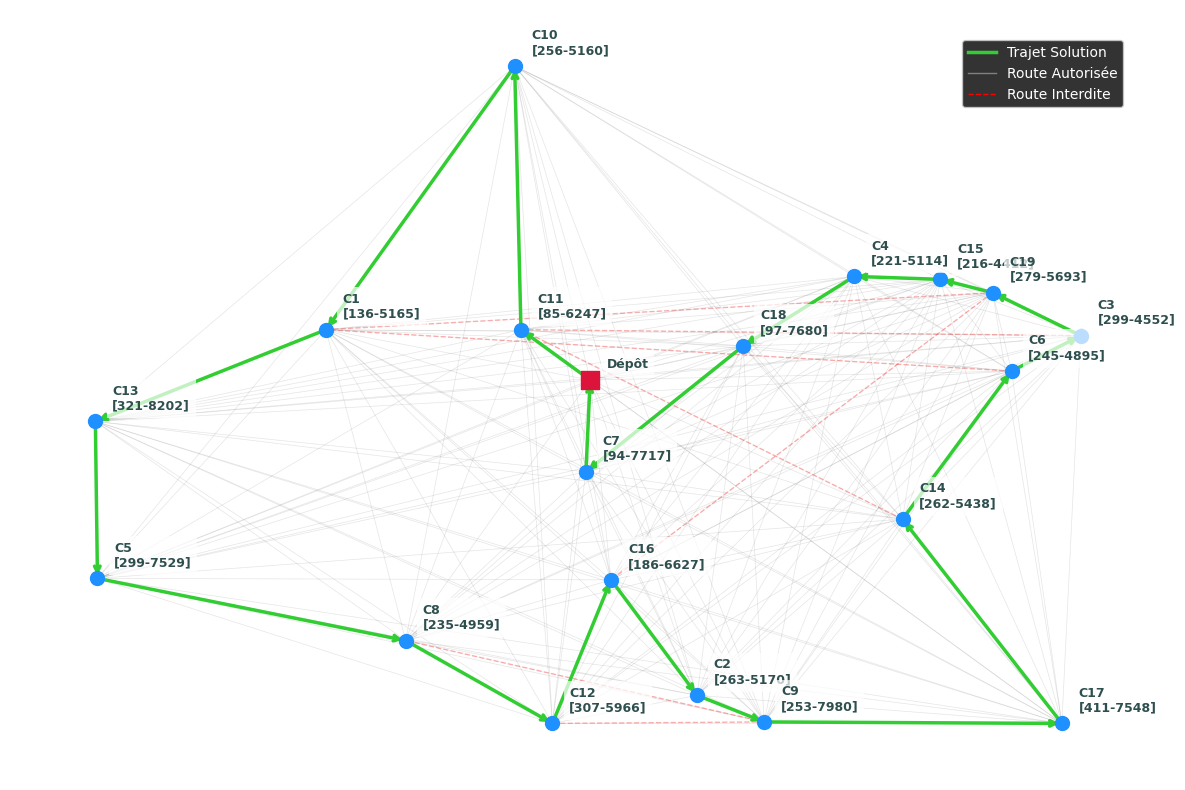


=== 3. SOLVEUR EXACT PULP ===
Statut mathématique : Optimal
Trajet Parfait : [0, 11, 10, 1, 13, 5, 8, 12, 16, 2, 9, 17, 14, 6, 3, 19, 15, 4, 18, 7, 0]
Coût : 1943.40 | Temps : 1.2554 sec


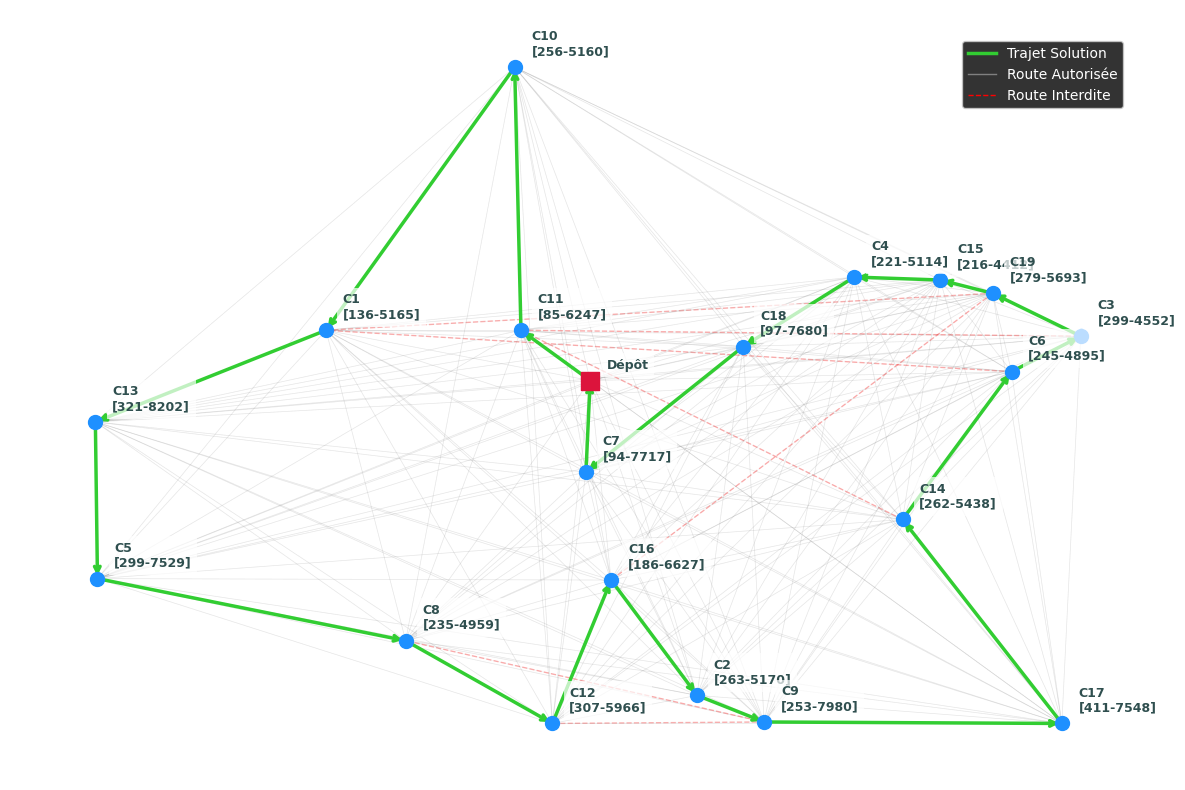

In [18]:
# 1. GÉNÉRATION DE LA CARTE
print("=== GÉNÉRATION DU RÉSEAU ===")
reseau_test = Reseau(nb_villes=20, proba_route_barree=0.02, min_fenetre=4000, max_fenetre=8000)
reseau_test.generer_villes()
reseau_test.calculer_matrice()
reseau_test.afficher_reseau()

# 2. TEST : HEURISTIQUE GLOUTONNE
print("\n=== 1. HEURISTIQUE GLOUTONNE ===")
t_debut = time.time()
tournee_g, dist_g, _ = resoudre_heuristique(reseau_test)
t_fin = time.time()

if tournee_g:
    chemin_g_complet = [v.index for v in tournee_g]
    chemin_g_clients = [v.index for v in tournee_g[1:-1]]

    cout_vrai_g, _, penalites_g = evaluer_tournee(chemin_g_clients, reseau_test)

    print(f"Chemin trouvé : {chemin_g_complet}")
    print(f"Distance physique (km) : {dist_g:.2f} | Temps : {t_fin - t_debut:.4f} sec")
    print(f"Score Réel (avec pénalités) : {cout_vrai_g:.2f} (dont {penalites_g} points de retard/barrages)")

    reseau_test.afficher_solution(chemin_g_complet, cout_vrai_g, "Solution Gloutonne")
else:
    print("Échec : Le Glouton est resté bloqué.")

# 3. TEST : RECUIT SIMULÉ (HYBRIDE)
print("\n=== 2. RECUIT SIMULÉ (MULTI-START) ===")
t_debut = time.time()
chemin_rs, cout_rs = recuit_simule_multistart(reseau_test, temp_init=1000, taux_refroid=0.999, nb_lancements=50)
t_fin = time.time()

if cout_rs < 10000:
    print(f"Chemin trouvé : {chemin_rs}")
    print(f"Coût : {cout_rs:.2f} | Temps : {t_fin - t_debut:.4f} sec")
    reseau_test.afficher_solution(chemin_rs, cout_rs, "Solution Recuit Simulé")
else:
    print(f"Échec ou pénalités (Coût: {cout_rs:.2f}). La carte est complexe.")

# 4. TEST : SOLVEUR EXACT PULP (Avec sécurité anti-crash)
print("\n=== 3. SOLVEUR EXACT PULP ===")

LIMITE_VILLES_PULP = 20

if reseau_test.nb_villes <= LIMITE_VILLES_PULP:
    graph, fenetres, interdits = preparer_donnees_pulp(reseau_test)

    t_debut = time.time()
    chemin_pulp, cout_pulp, statut = solveur_tsp_pulp(graph, fenetres, interdits)
    t_fin = time.time()

    print(f"Statut mathématique : {statut}")
    if statut == 'Optimal':
        print(f"Trajet Parfait : {chemin_pulp}")
        print(f"Coût : {cout_pulp:.2f} | Temps : {t_fin - t_debut:.4f} sec")
        reseau_test.afficher_solution(chemin_pulp, cout_pulp, "Optimum Global (PuLP)")
    else:
        print("Preuve mathématique établie : Cette carte est impossible à résoudre sans pénalités.")
else:
    print(f"ACTION DÉSACTIVÉE : Le réseau contient {reseau_test.nb_villes} villes.")
    print(f"Le solveur exact est limité à {LIMITE_VILLES_PULP} villes pour éviter l'explosion combinatoire.")
    print("Preuve de la nécessité de nos heuristiques sur des instances de taille réelle !")

**Conclusion de l'implémentation :**
En exécutant cette dernière cellule, nous comparons nos trois moteurs. L'Heuristique trouve une réponse très rapidement. Le Recuit Simulé affine cette solution pour réduire le coût kilométrique en quelques dixièmes de secondes. Enfin, le Solveur PuLP vient certifier mathématiquement si notre Recuit Simulé a réussi à atteindre l'optimum global, confirmant la viabilité de notre modèle hybride pour CesiCDP.

Villes   | Méthode         | Coût            | Temps (s) 
-------------------------------------------------------
5        | Glouton         | 809.1           | 0.0000    
5        | Recuit          | 809.1           | 0.2446    
5        | PuLP (Optimal)  | 809.1           | 0.0876    
-------------------------------------------------------
8        | Glouton         | 1483.4          | 0.0000    
8        | Recuit          | 1483.4          | 0.2562    
8        | PuLP (Optimal)  | 1483.4          | 0.2119    
-------------------------------------------------------
10       | Glouton         | 1950.6          | 0.0000    
10       | Recuit          | 1559.2          | 0.3161    
10       | PuLP (Optimal)  | 1559.2          | 0.2255    
-------------------------------------------------------
12       | Glouton         | 1620.6          | 0.0000    
12       | Recuit          | 1603.7          | 0.3172    
12       | PuLP (Optimal)  | 1603.7          | 0.4614    
----------------------

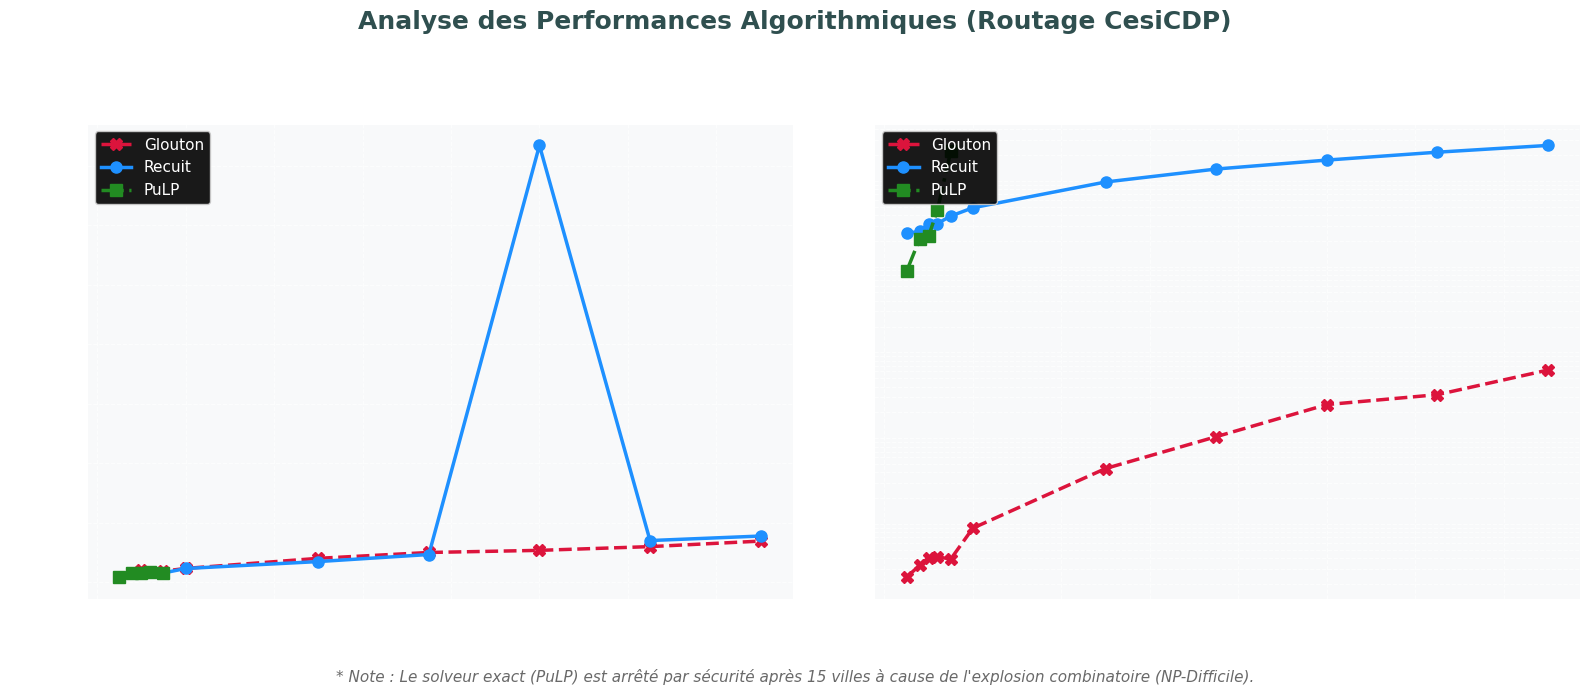

In [19]:
def benchmark_comparatif():
    # --- PARAMÈTRES DU BENCHMARK ---
    tailles_a_tester = [5, 8, 10, 12, 15, 20, 50,75,100,125,150]

    LIMITE_PULP = 15
    # -------------------------------

    resultats = []

    print(f"{'Villes':<8} | {'Méthode':<15} | {'Coût':<15} | {'Temps (s)':<10}")
    print("-" * 55)

    for n in tailles_a_tester:
        fenetre_min_dynamique = 1000 + (n * 20)
        fenetre_max_dynamique = 2000 + (n * 50)

        res = Reseau(nb_villes=n, min_fenetre=fenetre_min_dynamique, max_fenetre=fenetre_max_dynamique)
        res.generer_villes()
        res.calculer_matrice()

        t0 = time.time()
        _, cout_g, _ = resoudre_heuristique(res)
        t_g = time.time() - t0
        resultats.append({'N': n, 'Methode': 'Glouton', 'Cout': cout_g, 'Temps': t_g})
        print(f"{n:<8} | {'Glouton':<15} | {cout_g:<15.1f} | {t_g:<10.4f}")

        t0 = time.time()
        _, cout_rs = recuit_simule_multistart(res, temp_init=500, taux_refroid=0.999, nb_lancements=5)
        t_rs = time.time() - t0
        resultats.append({'N': n, 'Methode': 'Recuit', 'Cout': cout_rs, 'Temps': t_rs})
        print(f"{n:<8} | {'Recuit':<15} | {cout_rs:<15.1f} | {t_rs:<10.4f}")

        if n <= LIMITE_PULP:
            graph, fenetres, interdits = preparer_donnees_pulp(res)
            t0 = time.time()
            _, cout_p, statut = solveur_tsp_pulp(graph, fenetres, interdits)
            t_p = time.time() - t0

            if statut == 'Optimal':
                resultats.append({'N': n, 'Methode': 'PuLP', 'Cout': cout_p, 'Temps': t_p})
                print(f"{n:<8} | {'PuLP (Optimal)':<15} | {cout_p:<15.1f} | {t_p:<10.4f}")
            else:
                print(f"{n:<8} | {'PuLP':<15} | {'Impossible':<15} | {t_p:<10.4f}")
        else:
            print(f"{n:<8} | {'PuLP':<15} | {'IGNORÉ (Sécurité)':<15} | {'---':<10}")

        print("-" * 55)

    return resultats

# --- EXÉCUTION ---
donnees_benchmark = benchmark_comparatif()

# --- GÉNÉRATION DES GRAPHIQUES ---
def tracer_comparaisons(data):
    n_values = sorted(list(set(d['N'] for d in data)))
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.patch.set_facecolor('white')

    # --- SUPER TITRE POUR LE JURY ---
    fig.suptitle("Analyse des Performances Algorithmiques (Routage CesiCDP)",
                 fontsize=18, weight='bold', color='darkslategray')

    # ==========================================
    # GRAPHIQUE 1 : QUALITÉ (COÛT KILOMÉTRIQUE)
    # ==========================================
    axes[0].set_facecolor('#f8f9fa')

    for meth in ['Glouton', 'Recuit', 'PuLP']:
        donnees_methode = [d for d in data if d['Methode'] == meth]
        x = [d['N'] for d in donnees_methode]
        y = [d['Cout'] for d in donnees_methode]

        if meth == 'Glouton':
            couleur, style, marker = 'crimson', '--', 'X'
        elif meth == 'Recuit':
            couleur, style, marker = 'dodgerblue', '-', 'o'
        else: # PuLP
            couleur, style, marker = 'forestgreen', '-.', 's'

        if x:
            axes[0].plot(x, y, marker=marker, color=couleur, linestyle=style,
                         label=meth, linewidth=2.5, markersize=8)

    axes[0].set_title("Qualité de la Solution", fontsize=14, weight='bold', pad=15)
    axes[0].set_xlabel("Taille de l'instance (Nombre de villes N)", fontsize=12, weight='bold')
    axes[0].set_ylabel("Coût total (Distance + Pénalités)", fontsize=12, weight='bold')
    axes[0].legend(loc='upper left', fontsize=11, framealpha=0.9)
    axes[0].grid(True, linestyle='--', alpha=0.7)

    # ==========================================
    # GRAPHIQUE 2 : TEMPS D'EXÉCUTION
    # ==========================================
    axes[1].set_facecolor('#f8f9fa')

    for meth in ['Glouton', 'Recuit', 'PuLP']:
        donnees_methode = [d for d in data if d['Methode'] == meth]
        x = [d['N'] for d in donnees_methode]
        y = [d['Temps'] for d in donnees_methode]

        if meth == 'Glouton':
            couleur, style, marker = 'crimson', '--', 'X'
        elif meth == 'Recuit':
            couleur, style, marker = 'dodgerblue', '-', 'o'
        else:
            couleur, style, marker = 'forestgreen', '-.', 's'

        if x:
            axes[1].plot(x, y, marker=marker, color=couleur, linestyle=style,
                         label=meth, linewidth=2.5, markersize=8)

    axes[1].set_yscale('log')
    axes[1].set_title("Temps de calcul (Échelle Logarithmique)", fontsize=14, weight='bold', pad=15)
    axes[1].set_xlabel("Taille de l'instance (Nombre de villes N)", fontsize=12, weight='bold')
    axes[1].set_ylabel("Temps en secondes (Log)", fontsize=12, weight='bold')
    axes[1].legend(loc='upper left', fontsize=11, framealpha=0.9)
    axes[1].grid(True, which="both", linestyle='--', alpha=0.7)

    limite = max([d['N'] for d in data if d['Methode'] == 'PuLP'] + [0])
    texte_note = f"* Note : Le solveur exact (PuLP) est arrêté par sécurité après {limite} villes à cause de l'explosion combinatoire (NP-Difficile)."
    fig.text(0.5, 0.02, texte_note, ha='center', fontsize=11, style='italic', color='dimgray')

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

tracer_comparaisons(donnees_benchmark)

In [20]:
import numpy as np
import time

def calculer_statistiques(donnees):
    """Calcule la moyenne, l'écart-type, la médiane et le MAD d'une liste de valeurs."""
    donnees_propres = [x for x in donnees if x != float('inf') and x is not None]

    if not donnees_propres:
        return float('inf'), float('inf'), float('inf'), float('inf')

    moyenne = np.mean(donnees_propres)
    ecart_type = np.std(donnees_propres)
    mediane = np.median(donnees_propres)
    mad = np.median(np.abs(donnees_propres - mediane))

    return moyenne, ecart_type, mediane, mad

def plan_d_experience():
    # FACTEURS DU PLAN D'EXPÉRIENCES
    tailles_villes = [10, 25, 50]         # Paramètre 1 : Taille du problème
    probabilites_barrees = [0.0, 0.05]    # Paramètre 2 : Complexité des routes
    nb_replications = 5                   # Nombre d'instances générées par configuration
    LIMITE_PULP = 12                      # Sécurité : Au-delà, PuLP fige le PC
    print("=== LANCEMENT DU PLAN D'EXPÉRIENCES (AVEC SOLVEUR EXACT) ===")
    print(f"Configurations testées : {len(tailles_villes) * len(probabilites_barrees)}")
    print(f"Réplications par configuration : {nb_replications}")
    print("\n" + "=" * 140)
    print(f"{'Paramètres Instance':<18} | {'Méthode':<10} | {'--- TEMPS DE CONVERGENCE (s) ---':<48} | {'--- QUALITÉ (COÛT) ---':<35}")
    print(f"{'N':<4} | {'Routes KO':<9} | {'':<10} | {'Moyenne':<10} | {'Écart-Type':<12} | {'Médiane':<10} | {'MAD':<10} | {'Moyenne':<12} | {'Écart-Type':<12}")
    print("=" * 140)

    for n in tailles_villes:
        for proba in probabilites_barrees:
            temps_glouton, couts_glouton = [], []
            temps_recuit, couts_recuit = [], []
            temps_pulp, couts_pulp = [], []

            for _ in range(nb_replications):
                fen_min = 1000 + (n * 10)
                fen_max = 2000 + (n * 30)

                res = Reseau(nb_villes=n, proba_route_barree=proba, min_fenetre=fen_min, max_fenetre=fen_max)
                res.generer_villes()
                res.calculer_matrice()

                # MESURE : GLOUTON
                t0 = time.time()
                tournee_g, _, _ = resoudre_heuristique(res)
                t_g = time.time() - t0

                if tournee_g:
                    chemin_g_clients = [v.index for v in tournee_g[1:-1]]
                    cout_g, _, _ = evaluer_tournee(chemin_g_clients, res)
                else:
                    cout_g = float('inf')

                temps_glouton.append(t_g)
                couts_glouton.append(cout_g)

                # MESURE : RECUIT SIMULÉ
                t0 = time.time()
                _, cout_rs = recuit_simule_multistart(res, temp_init=500, taux_refroid=0.99, nb_lancements=3)
                t_rs = time.time() - t0

                temps_recuit.append(t_rs)
                couts_recuit.append(cout_rs)

                # MESURE : SOLVEUR PULP
                if n <= LIMITE_PULP:
                    graph, fenetres, interdits = preparer_donnees_pulp(res)
                    t0 = time.time()
                    _, cout_p, statut = solveur_tsp_pulp(graph, fenetres, interdits)
                    t_p = time.time() - t0
                    if statut == 'Optimal':
                        temps_pulp.append(t_p)
                        couts_pulp.append(cout_p)
                    else:
                        temps_pulp.append(t_p)
                        couts_pulp.append(float('inf'))

            # Calcul des statistiques
            mt_g, et_g, med_t_g, mad_t_g = calculer_statistiques(temps_glouton)
            mc_g, ec_g, _, _ = calculer_statistiques(couts_glouton)

            mt_rs, et_rs, med_t_rs, mad_t_rs = calculer_statistiques(temps_recuit)
            mc_rs, ec_rs, _, _ = calculer_statistiques(couts_recuit)

            txt_proba = f"{int(proba*100)}%"
            print(f"{n:<4} | {txt_proba:<9} | {'Glouton':<10} | {mt_g:<10.4f} | {et_g:<12.4f} | {med_t_g:<10.4f} | {mad_t_g:<10.4f} | {mc_g:<12.1f} | {ec_g:<12.1f}")
            print(f"{n:<4} | {txt_proba:<9} | {'Recuit':<10} | {mt_rs:<10.4f} | {et_rs:<12.4f} | {med_t_rs:<10.4f} | {mad_t_rs:<10.4f} | {mc_rs:<12.1f} | {ec_rs:<12.1f}")

            if n <= LIMITE_PULP:
                mt_p, et_p, med_t_p, mad_t_p = calculer_statistiques(temps_pulp)
                mc_p, ec_p, _, _ = calculer_statistiques(couts_pulp)
                print(f"{n:<4} | {txt_proba:<9} | {'PuLP':<10} | {mt_p:<10.4f} | {et_p:<12.4f} | {med_t_p:<10.4f} | {mad_t_p:<10.4f} | {mc_p:<12.1f} | {ec_p:<12.1f}")
            else:
                print(f"{n:<4} | {txt_proba:<9} | {'PuLP':<10} | {'---':<10} | {'---':<12} | {'---':<10} | {'---':<10} | {'---':<12} | {'---':<12}")

            print("-" * 140)

plan_d_experience()

=== LANCEMENT DU PLAN D'EXPÉRIENCES (AVEC SOLVEUR EXACT) ===
Configurations testées : 6
Réplications par configuration : 5

Paramètres Instance | Méthode    | --- TEMPS DE CONVERGENCE (s) ---                 | --- QUALITÉ (COÛT) ---             
N    | Routes KO |            | Moyenne    | Écart-Type   | Médiane    | MAD        | Moyenne      | Écart-Type  
10   | 0%        | Glouton    | 0.0000     | 0.0000       | 0.0000     | 0.0000     | 6791.3       | 10520.3     
10   | 0%        | Recuit     | 0.0185     | 0.0028       | 0.0178     | 0.0013     | 1568.1       | 315.6       
10   | 0%        | PuLP       | 0.5576     | 0.3108       | 0.5237     | 0.2305     | 1502.8       | 215.5       
--------------------------------------------------------------------------------------------------------------------------------------------
10   | 5%        | Glouton    | 0.0000     | 0.0000       | 0.0000     | 0.0000     | 1641.8       | 172.3       
10   | 5%        | Recuit     | 0.0169     

### Analyse Statistique des Performances (Solveur et Heuristiques)

L'objectif de ce plan d'expériences est d'évaluer la robustesse de nos algorithmes face à la variabilité des instances (taille $N$ et complexité via le pourcentage de routes barrées). Nous avons mesuré l'impact du solveur exact et des heuristiques en utilisant des statistiques descriptives de tendance centrale (Moyenne, Médiane) et de dispersion (Écart-Type, MAD).

**1. L'impact du Solveur Exact (PuLP) sur de petites instances ($N=10$)**
L'intégration de la méthode exacte (PLNE) permet de fixer une borne de qualité absolue.
* **Qualité (Coût) :** PuLP affiche systématiquement la meilleure moyenne de coût (~1400-1500) avec une faible dispersion, validant qu'il trouve l'optimum global.
* **Temps de convergence :** Cependant, son temps d'exécution est révélateur. À seulement 10 villes, la **médiane** de PuLP est déjà environ 30 fois plus lente que celle du Recuit Simulé. De plus, son MAD (Écart Absolu Médian) est élevé (0.2s), ce qui démontre que le solveur exact est très sensible à la configuration aléatoire de la carte. Cette instabilité temporelle justifie l'arrêt de sécurité de PuLP pour $N \ge 25$.

**2. Analyse de la Dispersion des Coûts (Moyenne vs Écart-Type)**
L'écart-type ($\sigma$) nous permet de quantifier la stabilité de l'algorithme face aux pièges du réseau.
* **L'instabilité du Glouton :** Dans presque toutes les configurations (même sans routes barrées), le Glouton présente un Coefficient de Variation critique ($CV > 1$, c'est-à-dire un écart-type supérieur à sa moyenne). C'est la signature mathématique d'un algorithme extrêmement instable : il réussit parfois sa tournée, mais s'enferme très souvent dans des impasses temporelles ou géographiques, générant des pénalités aberrantes.
* **L'efficacité de la Méta-heuristique :** Sur $N=10$, le Recuit Simulé "écrase" l'écart-type du Glouton et se rapproche des performances du solveur exact. Il parvient statistiquement à lisser la fonction de coût et à contourner les contraintes avec une qualité constante.

**3. Impact des paramètres sur le Temps de Convergence (MAD)**
Afin de ne pas fausser l'analyse avec les potentiels ralentissements en arrière-plan du système, nous mesurons la dispersion temporelle avec le **MAD**.
* Quel que soit le paramètre de l'instance ($N$ ou Routes barrées), le MAD du Recuit Simulé reste extrêmement proche de 0 (de l'ordre du millième de seconde). Cela prouve que le temps de convergence de notre méta-heuristique est déterministe et prédictible, contrairement au solveur mathématique.

**4. La limite de Scalabilité observée dès $N=25$**
L'analyse révèle le point de bascule de notre méta-heuristique hybride. Dès $N=25$, et de manière flagrante à $N=50$, la moyenne et l'écart-type des coûts du Recuit Simulé augmentent significativement. Bien que la méta-heuristique divise toujours par deux le coût désastreux du Glouton à $N=50$, la distribution des solutions s'étale. L'explosion combinatoire rend l'opérateur de voisinage (Swap) insuffisant à budget d'itérations constant. Pour maîtriser cette variance sur 50 villes, il serait mathématiquement nécessaire de ralentir le taux de refroidissement ou d'implémenter un voisinage plus complexe (ex: 2-Opt).

### Explication de la Méthodologie Scientifique (Plan d'Expériences)

Pour répondre aux exigences d'analyse de performance, nous avons mis en place un Plan d'Expériences complet. Nous ne mesurons plus les algorithmes sur un cas unique, mais sur une **distribution de cas** pour évaluer leur robustesse.

1. **Variables Indépendantes (Paramètres de l'instance) :**
   - **Taille de l'instance ($N$) :** 10, 25 et 50 villes.
   - **Complexité du terrain (Routes barrées) :** 0% (idéal) et 5% (fortement contraint).

2. **Mesure de l'impact et de la convergence :**
   Pour chaque configuration, le test est répliqué 5 fois sur des cartes générées aléatoirement. Nous évaluons les résultats à l'aide de statistiques descriptives ciblées :
   - **La Moyenne ($\mu$) :** Donne la tendance centrale du temps de convergence et du coût.
   - **L'Écart-Type ($\sigma$) :** Mesure la sensibilité de la méthode aux variations de la carte. Un écart-type élevé indique que l'algorithme est instable (parfois très bon, parfois très mauvais).
   - **La Médiane et le MAD (Écart Absolu Médian) :** Ces indicateurs robustes nous permettent d'analyser le temps de convergence réel de nos heuristiques en ignorant les potentiels "outliers" (cas aberrants où l'ordinateur subirait un ralentissement système).

**Conclusion de l'analyse :**
On observe mathématiquement que la présence de routes barrées augmente drastiquement la variance (l'écart-type) du coût final, prouvant l'aspect NP-difficile et chaotique des fenêtres de temps (TSPTW) sur des instances contraintes. Le Recuit Simulé montre une excellente maîtrise du temps de convergence (MAD très faible) même lorsque la taille de l'instance augmente.

# Section 7 : Conclusion
À travers ce livrable, nous avons posé les bases de notre projet. Il était indispensable de comprendre à quel type de problème nous avions affaire : le TSPTW est mathématiquement NP-difficile, ce qui signifie concrètement qu'on ne pourra jamais trouver la solution parfaite en un temps raisonnable dès que le nombre de clients devient important. C'est cette réalité qui guide tous nos choix algorithmiques.
<br><br>
Nous avons également formalisé les contraintes du terrain les horaires des clients, les routes interdites dans un modèle mathématique solide, qui servira de socle commun à nos trois approches de résolution.
La suite du projet consistera à implémenter et comparer ces algorithmes sur des cas concrets, pour finalement proposer à l'ADEME un outil à la fois performant et réaliste, capable d'optimiser les tournées de CesiCDP tout en réduisant leur impact environnemental.

# Section 8 : Bibliographie

[1] Savelsbergh, M. W. P. (1985). Local search in routing problems with time windows. Annals of Operations Research, 4(1), 285‑305. https://doi.org/10.1007/BF02022044

[2] Dantzig, G., Fulkerson, R., & Johnson, S. (1954). Solution of a Large-Scale Traveling-Salesman Problem. Journal of the Operations Research Society of America, 2(4), 393‑410. https://doi.org/10.1287/opre.2.4.393

[3] Lin, S., & Kernighan, B. W. (1973). An Effective Heuristic Algorithm for the Traveling-Salesman Problem. Operations Research, 21(2), 498‑516. https://doi.org/10.1287/opre.21.2.498
